In [27]:
from pathlib import Path
import sys
import math
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from typing import Optional, Tuple, Union


from src.perturbation_methods.perturbation_methods import *

DATASET_ROOT = Path("~/scratch/segmentation_dataset_v1").expanduser()

PHISAT2_IMAGE_DIR = DATASET_ROOT / "images_phisat2_npy"
S2_IMAGE_DIR = DATASET_ROOT / "images_s2_npy"

SQRT_CLIP = math.sqrt(1500.0)

# PhiSat-2 normalization constants from data_loader.py
PHISAT2_MEAN = np.array(
    [15.0381, 14.5305, 14.4030, 15.4191, 13.6231, 14.2143, 14.7041, 13.1745],
    dtype=np.float32,
)

PHISAT2_STD = np.array(
    [8.2196, 10.6197, 9.4811, 9.0923, 10.5712, 10.4277, 10.3784, 9.7216],
    dtype=np.float32,
)

# Sentinel-2 normalization constants from data_loader.py
S2B_MEAN = np.array(
    [49.0215, 48.4241, 49.2270, 51.1619, 55.4031, 57.3537, 56.7685],
    dtype=np.float32,
)

S2B_STD = np.array(
    [6.5464, 6.9918, 9.1444, 8.3999, 7.9740, 8.3373, 8.4429],
    dtype=np.float32,
)

S2B_MIN = np.array(
    [0.0, -32701.0, 0.0, 0.0, 0.0, 0.0, -32690.0],
    dtype=np.float32,
)

S2B_MAX = np.array(
    [31463.0, 32724.0, 32218.0, 29106.0, 29044.0, 29031.0, 32424.0],
    dtype=np.float32,
)

from typing import Union


def _resolve_image_path(
    image_dir: Path,
    patch_id: Union[str, int],
    pad_widths: Tuple[int, ...] = (6, 7, 8),
) -> Path:
    """
    Resolve image paths with optional zero-padding.

    Examples:
        patch_id=2267 can resolve to:
            image_2267.npy
            image_002267.npy
            image_0002267.npy
            image_00002267.npy
    """
    patch_id = str(patch_id)

    candidates = []

    if patch_id.endswith(".npy"):
        candidates.append(image_dir / patch_id)

        stem = Path(patch_id).stem
        numeric = stem.replace("image_", "", 1)

    elif patch_id.startswith("image_"):
        candidates.append(image_dir / f"{patch_id}.npy")
        numeric = patch_id.replace("image_", "", 1)

    else:
        candidates.append(image_dir / f"image_{patch_id}.npy")
        numeric = patch_id

    if numeric.isdigit():
        numeric_int = int(numeric)

        for width in pad_widths:
            candidates.append(image_dir / f"image_{numeric_int:0{width}d}.npy")

    # Remove duplicates
    candidates = list(dict.fromkeys(candidates))

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Could not find patch file.\n"
        f"image_dir: {image_dir}\n"
        f"patch_id: {patch_id}\n"
        "Checked:\n"
        + "\n".join(str(p) for p in candidates)
    )

def normalize_phisat2(x: np.ndarray) -> np.ndarray:
    """
    Match PhiSatSegDataset.normalize_().

    Input:
        raw PhiSat-2 patch, shape (8, 256, 256)

    Output:
        normalized PhiSat-2 patch, shape (8, 256, 256)
    """
    x = x.astype(np.float32)

    x = np.sqrt(np.clip(x, 0.0, None))
    x = np.clip(x, 0.0, SQRT_CLIP)

    x = (x - PHISAT2_MEAN[:, None, None]) / (PHISAT2_STD[:, None, None] + 1e-6)

    return x.astype(np.float32)


def normalize_s2(x: np.ndarray) -> np.ndarray:
    """
    Match Sentinel2SegDataset.normalize_().

    Input:
        raw Sentinel-2 patch, shape (7, 128, 128)

    Output:
        normalized Sentinel-2 patch, shape (7, 128, 128)
    """
    x = x.astype(np.float32)

    x = np.clip(
        x,
        S2B_MIN[:, None, None],
        S2B_MAX[:, None, None],
    )

    x = (x - S2B_MEAN[:, None, None]) / (S2B_STD[:, None, None] + 1e-6)

    return x.astype(np.float32)



def load_patches(patch_id: Union[str, int]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load the same patch ID for PhiSat-2 and Sentinel-2.

    Returns raw, unnormalized arrays:
        x_phisat2: shape (8, 256, 256)
        x_s2:      shape (7, 128, 128)
    """
    phisat2_path = _resolve_image_path(PHISAT2_IMAGE_DIR, patch_id)
    s2_path = _resolve_image_path(S2_IMAGE_DIR, patch_id)

    x_phisat2 = np.load(phisat2_path).astype(np.float32)
    x_s2 = np.load(s2_path).astype(np.float32)

    if x_phisat2.shape != (8, 256, 256):
        raise ValueError(
            f"Expected PhiSat-2 shape (8, 256, 256), got {x_phisat2.shape}: "
            f"{phisat2_path}"
        )

    if x_s2.shape != (7, 128, 128):
        raise ValueError(
            f"Expected Sentinel-2 shape (7, 128, 128), got {x_s2.shape}: "
            f"{s2_path}"
        )

    print(f"Loaded PhiSat-2:   {phisat2_path.name}")
    print(f"Loaded Sentinel-2: {s2_path.name}")

    return x_phisat2, x_s2


def normalize_for_plot(
    x: np.ndarray,
    sensor: str,
) -> np.ndarray:
    """
    Normalize a raw patch using the same preprocessing as data_loader.py.

    sensor:
        "phisat2" or "s2"
    """
    sensor = sensor.lower()

    if sensor in {"phisat2", "phi-sat-2", "phi_sat_2"}:
        return normalize_phisat2(x)

    if sensor in {"s2", "sentinel2", "sentinel-2"}:
        return normalize_s2(x)

    raise ValueError("sensor must be 'phisat2' or 's2'")


def robust_minmax(
    img: np.ndarray,
    lower: float = 2.0,
    upper: float = 98.0,
) -> np.ndarray:
    """
    Convert one 2D image or one RGB image to [0, 1] for display.

    This is only for visualization. It does not change training data.
    """
    img = img.astype(np.float32)

    lo, hi = np.percentile(img, [lower, upper])

    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)

    img = (img - lo) / (hi - lo)
    img = np.clip(img, 0.0, 1.0)

    return img.astype(np.float32)


def get_rgb_indices(sensor: str) -> Tuple[int, int, int]:
    """
    Return RGB band indices for each sensor.

    PhiSat-2 band order:
        0 PAN
        1 Blue
        2 Green
        3 Red
        4 Red Edge 1
        5 Red Edge 2
        6 Red Edge 3
        7 NIR

    Sentinel-2B band order:
        0 B02 Blue
        1 B03 Green
        2 B04 Red
        3 B05 Red Edge 1
        4 B06 Red Edge 2
        5 B07 Red Edge 3
        6 B08 NIR

    Returns:
        (red_index, green_index, blue_index)
    """
    sensor = sensor.lower()

    if sensor in {"phisat2", "phi-sat-2", "phi_sat_2"}:
        return (3, 2, 1)

    if sensor in {"s2", "sentinel2", "sentinel-2", "s2b", "sentinel-2b"}:
        return (2, 1, 0)

    raise ValueError("sensor must be 'phisat2' or 's2'")

    
def make_rgb_for_plot(
    x: np.ndarray,
    sensor: str,
    rgb_indices: Optional[Tuple[int, int, int]] = None,
    normalize: bool = True,
) -> np.ndarray:
    """
    Create a true-color RGB visualization from a raw or already-normalized patch.

    Default RGB mappings:
        PhiSat-2:    Red=3, Green=2, Blue=1
        Sentinel-2B: Red=2, Green=1, Blue=0

    Set normalize=False if x is already normalized or already perturbed
    in normalized space.
    """
    sensor = sensor.lower()

    if normalize:
        x_plot = normalize_for_plot(x, sensor)
    else:
        x_plot = x.astype(np.float32)

    if rgb_indices is None:
        rgb_indices = get_rgb_indices(sensor)

    rgb = np.stack(
        [
            x_plot[rgb_indices[0]],  # Red
            x_plot[rgb_indices[1]],  # Green
            x_plot[rgb_indices[2]],  # Blue
        ],
        axis=-1,
    )

    return robust_minmax(rgb)


def plot_patch_rgb(
    x: np.ndarray,
    sensor: str,
    title: Optional[str] = None,
    rgb_indices: Optional[Tuple[int, int, int]] = None,
    normalize: bool = True,
    figsize: Tuple[int, int] = (5, 5),
):
    """
    Plot one patch as RGB.

    Important:
        If x is raw, use normalize=True.
        If x has already been normalized/perturbed in normalized space,
        use normalize=False.
    """
    rgb = make_rgb_for_plot(
        x=x,
        sensor=sensor,
        rgb_indices=rgb_indices,
        normalize=normalize,
    )

    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.axis("off")

    if title is None:
        title = sensor

    plt.title(title)
    plt.show()


def plot_patches_side_by_side(
    x_phisat2: np.ndarray,
    x_s2: np.ndarray,
    normalize: bool = True,
):
    """
    Plot PhiSat-2 and Sentinel-2 RGB views next to each other.

    If x_phisat2 and x_s2 are raw outputs from load_patches(), keep normalize=True.
    """
    rgb_phisat2 = make_rgb_for_plot(
        x_phisat2,
        sensor="phisat2",
        normalize=normalize,
    )

    rgb_s2 = make_rgb_for_plot(
        x_s2,
        sensor="s2",
        normalize=normalize,
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(rgb_phisat2)
    axes[0].set_title("PhiSat-2")
    axes[0].axis("off")

    axes[1].imshow(rgb_s2)
    axes[1].set_title("Sentinel-2")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

Loaded PhiSat-2:   image_101603.npy
Loaded Sentinel-2: image_101603.npy
(8, 256, 256) (7, 128, 128)


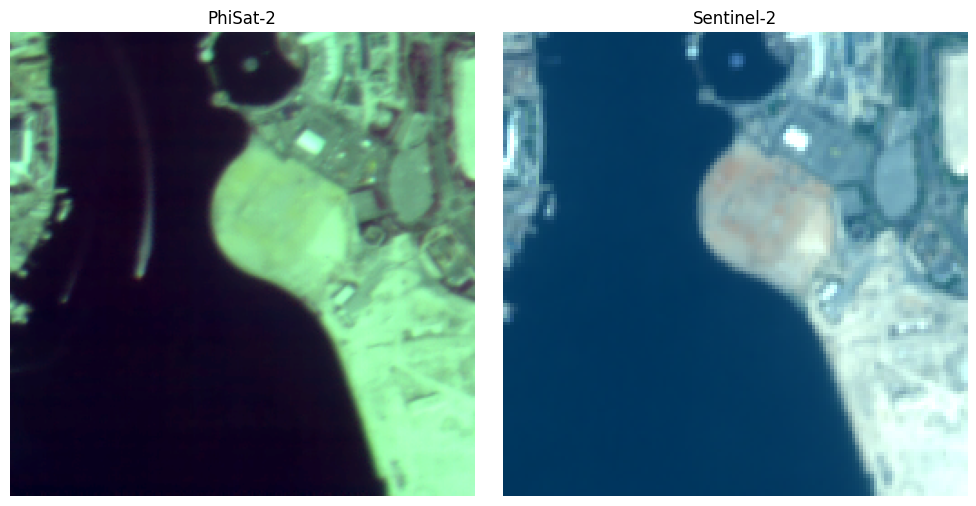

In [26]:
x_phisat2_raw, x_s2_raw = load_patches("101603")

print(x_phisat2_raw.shape, x_s2_raw.shape)

plot_patches_side_by_side(x_phisat2_raw, x_s2_raw, normalize=True)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


SNR_STRENGTHS = np.logspace(0, -2, 9).astype(np.float32)
# [1.0, 0.562, 0.316, 0.178, 0.1, 0.0562, 0.0316, 0.0178, 0.01]


# Your actual PhiSat-2 data order:
# [PAN, Blue, Green, Red, RE1, RE2, RE3, NIR]
#
# The imported perturbation file assumes PAN is index 3, but your data has PAN at index 0.
# So we override PhiSat-2 SNR and Lref here for the actual data order.
PHISAT2_SNR_DATA_ORDER = np.array(
    [256.0, 91.5, 91.5, 91.5, 91.5, 91.5, 91.5, 91.5],
    dtype=np.float32,
)

# Approximate Lref in your actual PhiSat-2 data order:
# PAN approximated from S2 B02-B06;
# Blue/Green/Red/RE1/RE2/RE3/NIR mapped from S2 B02-B08.
PHISAT2_LREF_DATA_ORDER = np.array(
    [
        np.mean([128.00, 128.00, 108.00, 74.60, 68.23]),  # PAN approx
        128.00,  # Blue  ~ S2 B02
        128.00,  # Green ~ S2 B03
        108.00,  # Red   ~ S2 B04
        74.60,   # RE1   ~ S2 B05
        68.23,   # RE2   ~ S2 B06
        66.70,   # RE3   ~ S2 B07
        103.00,  # NIR   ~ S2 B08
    ],
    dtype=np.float32,
)

# Sentinel-2B actual data order:
# [B02, B03, B04, B05, B06, B07, B08]
S2_SNR_DATA_ORDER = np.array(
    [154.0, 168.0, 142.0, 117.0, 89.0, 105.0, 174.0],
    dtype=np.float32,
)

S2_LREF_DATA_ORDER = np.array(
    [128.00, 128.00, 108.00, 74.60, 68.23, 66.70, 103.00],
    dtype=np.float32,
)


def mae(x_ref: np.ndarray, x_pert: np.ndarray) -> float:
    return float(np.mean(np.abs(x_ref - x_pert)))


def _sample_pixel_vectors(
    x: np.ndarray,
    max_samples: int = 4096,
    seed: int = 42,
) -> np.ndarray:
    """
    Convert C,H,W image to N,C pixel vectors and subsample.
    """
    c, h, w = x.shape
    vectors = np.moveaxis(x, 0, -1).reshape(-1, c).astype(np.float32)

    if vectors.shape[0] <= max_samples:
        return vectors

    rng = np.random.default_rng(seed)
    idx = rng.choice(vectors.shape[0], size=max_samples, replace=False)
    return vectors[idx]


def _median_heuristic_sigma(
    x: np.ndarray,
    y: np.ndarray,
    max_pairs: int = 2048,
) -> float:
    """
    Estimate RBF bandwidth from pairwise distances.
    """
    z = np.concatenate([x, y], axis=0)

    if z.shape[0] > max_pairs:
        rng = np.random.default_rng(123)
        idx = rng.choice(z.shape[0], size=max_pairs, replace=False)
        z = z[idx]

    diffs = z[:, None, :] - z[None, :, :]
    d2 = np.sum(diffs * diffs, axis=-1)
    d2 = d2[d2 > 0]

    if len(d2) == 0:
        return 1.0

    sigma = np.sqrt(0.5 * np.median(d2))
    return float(max(sigma, 1e-6))


def mmd_rbf(
    x_ref: np.ndarray,
    x_pert: np.ndarray,
    max_samples: int = 4096,
    seed: int = 42,
    sigma: Optional[float] = None,
) -> float:
    """
    Biased RBF-MMD² between two C,H,W images.

    Each pixel is treated as one C-dimensional sample.
    """
    x = _sample_pixel_vectors(x_ref, max_samples=max_samples, seed=seed)
    y = _sample_pixel_vectors(x_pert, max_samples=max_samples, seed=seed + 1)

    if sigma is None:
        sigma = _median_heuristic_sigma(x, y)

    gamma = 1.0 / (2.0 * sigma * sigma)

    def kernel_mean(a, b):
        d2 = np.sum((a[:, None, :] - b[None, :, :]) ** 2, axis=-1)
        return np.exp(-gamma * d2).mean()

    k_xx = kernel_mean(x, x)
    k_yy = kernel_mean(y, y)
    k_xy = kernel_mean(x, y)

    mmd2 = k_xx + k_yy - 2.0 * k_xy
    return float(max(mmd2, 0.0))


def apply_snr_before_normalization(
    x_raw: np.ndarray,
    sensor: str,
    snr_factor: float,
    seed: int = 42,
    use_official_lref: bool = True,
) -> np.ndarray:
    """
    Apply SNR perturbation in raw image space.

    If use_official_lref=True:
        sigma_b = Lref_b / SNR_b

    If use_official_lref=False:
        sigma_b = mean(x_b) / SNR_b

    For raw radiance-like inputs, use_official_lref=True is the physically intended setting.
    """
    sensor = sensor.lower()

    if sensor in {"phisat2", "phi-sat-2", "phi_sat_2"}:
        return perturb_snr(
            x_raw,
            snr_b=PHISAT2_SNR_DATA_ORDER,
            lref_b=PHISAT2_LREF_DATA_ORDER,
            snr_factor=snr_factor,
            seed=seed,
            use_official_lref=use_official_lref,
        ).astype(np.float32)

    if sensor in {"s2", "s2b", "sentinel2", "sentinel-2", "sentinel-2b"}:
        return perturb_snr(
            x_raw,
            snr_b=S2_SNR_DATA_ORDER,
            lref_b=S2_LREF_DATA_ORDER,
            snr_factor=snr_factor,
            seed=seed,
            use_official_lref=use_official_lref,
        ).astype(np.float32)

    raise ValueError("sensor must be 'phisat2' or 's2'")


def normalize_by_sensor(x_raw: np.ndarray, sensor: str) -> np.ndarray:
    sensor = sensor.lower()

    if sensor in {"phisat2", "phi-sat-2", "phi_sat_2"}:
        return normalize_phisat2(x_raw)

    if sensor in {"s2", "s2b", "sentinel2", "sentinel-2", "sentinel-2b"}:
        return normalize_s2(x_raw)

    raise ValueError("sensor must be 'phisat2' or 's2'")


def run_snr_sweep_before_and_after_norm(
    x_phisat2_raw: np.ndarray,
    x_s2_raw: np.ndarray,
    strengths: np.ndarray = SNR_STRENGTHS,
    seed: int = 42,
    max_mmd_samples: int = 4096,
    use_official_lref: bool = True,
):
    """
    For each sensor and SNR factor:

        1. apply SNR to raw image
        2. compute raw-space MAE/MMD
        3. normalize clean raw image
        4. normalize perturbed raw image
        5. compute normalized-space MAE/MMD

    Returns:
        results: DataFrame
        clean_raw: dict
        clean_norm: dict
        perturbed_raw: dict
        perturbed_norm: dict
    """
    clean_raw = {
        "PhiSat-2": x_phisat2_raw.astype(np.float32),
        "Sentinel-2B": x_s2_raw.astype(np.float32),
    }

    sensor_keys = {
        "PhiSat-2": "phisat2",
        "Sentinel-2B": "s2",
    }

    clean_norm = {
        sensor_name: normalize_by_sensor(x_raw, sensor_keys[sensor_name])
        for sensor_name, x_raw in clean_raw.items()
    }

    perturbed_raw = {
        "PhiSat-2": {},
        "Sentinel-2B": {},
    }

    perturbed_norm = {
        "PhiSat-2": {},
        "Sentinel-2B": {},
    }

    rows = []

    for sensor_name, x_clean_raw in clean_raw.items():
        sensor_key = sensor_keys[sensor_name]
        x_clean_norm = clean_norm[sensor_name]

        for strength in strengths:
            strength = float(strength)

            x_noisy_raw = apply_snr_before_normalization(
                x_clean_raw,
                sensor=sensor_key,
                snr_factor=strength,
                seed=seed,
                use_official_lref=use_official_lref,
            )

            x_noisy_norm = normalize_by_sensor(x_noisy_raw, sensor_key)

            perturbed_raw[sensor_name][strength] = x_noisy_raw
            perturbed_norm[sensor_name][strength] = x_noisy_norm

            rows.append(
                {
                    "sensor": sensor_name,
                    "snr_factor": strength,

                    "mae_raw": mae(x_clean_raw, x_noisy_raw),
                    "mmd_raw": mmd_rbf(
                        x_clean_raw,
                        x_noisy_raw,
                        max_samples=max_mmd_samples,
                        seed=seed,
                    ),

                    "mae_norm": mae(x_clean_norm, x_noisy_norm),
                    "mmd_norm": mmd_rbf(
                        x_clean_norm,
                        x_noisy_norm,
                        max_samples=max_mmd_samples,
                        seed=seed,
                    ),
                }
            )

    results = pd.DataFrame(rows)
    return results, clean_raw, clean_norm, perturbed_raw, perturbed_norm

In [32]:
patch_id = overlap[0]

x_phisat2_raw, x_s2_raw = load_patches(patch_id)

snr_results, clean_raw, clean_norm, perturbed_raw, perturbed_norm = run_snr_sweep_before_and_after_norm(
    x_phisat2_raw,
    x_s2_raw,
    strengths=SNR_STRENGTHS,
    seed=42,
    use_official_lref=True,
)

snr_results

Loaded PhiSat-2:   image_002267.npy
Loaded Sentinel-2: image_2267.npy


,sensor,snr_factor,mae_raw,mmd_raw,mae_norm,mmd_norm
0,PhiSat-2,1.000000,0.777223,0.000610,0.002452,0.000629
1,PhiSat-2,0.562341,1.382120,0.000611,0.004360,0.000636
2,PhiSat-2,0.316228,2.457795,0.000618,0.007756,0.000656
3,PhiSat-2,0.177828,4.370646,0.000634,0.013805,0.000734
4,PhiSat-2,0.100000,7.772230,0.000699,0.024627,0.001069
5,PhiSat-2,0.056234,13.821198,0.000964,0.044353,0.003133
6,PhiSat-2,0.031623,24.577955,0.002351,0.079643,0.013349
7,PhiSat-2,0.017783,43.706459,0.010298,0.139758,0.034887
8,PhiSat-2,0.010000,77.722298,0.038979,0.242185,0.076314
9,Sentinel-2B,1.000000,0.569151,0.000060,0.072787,0.000061


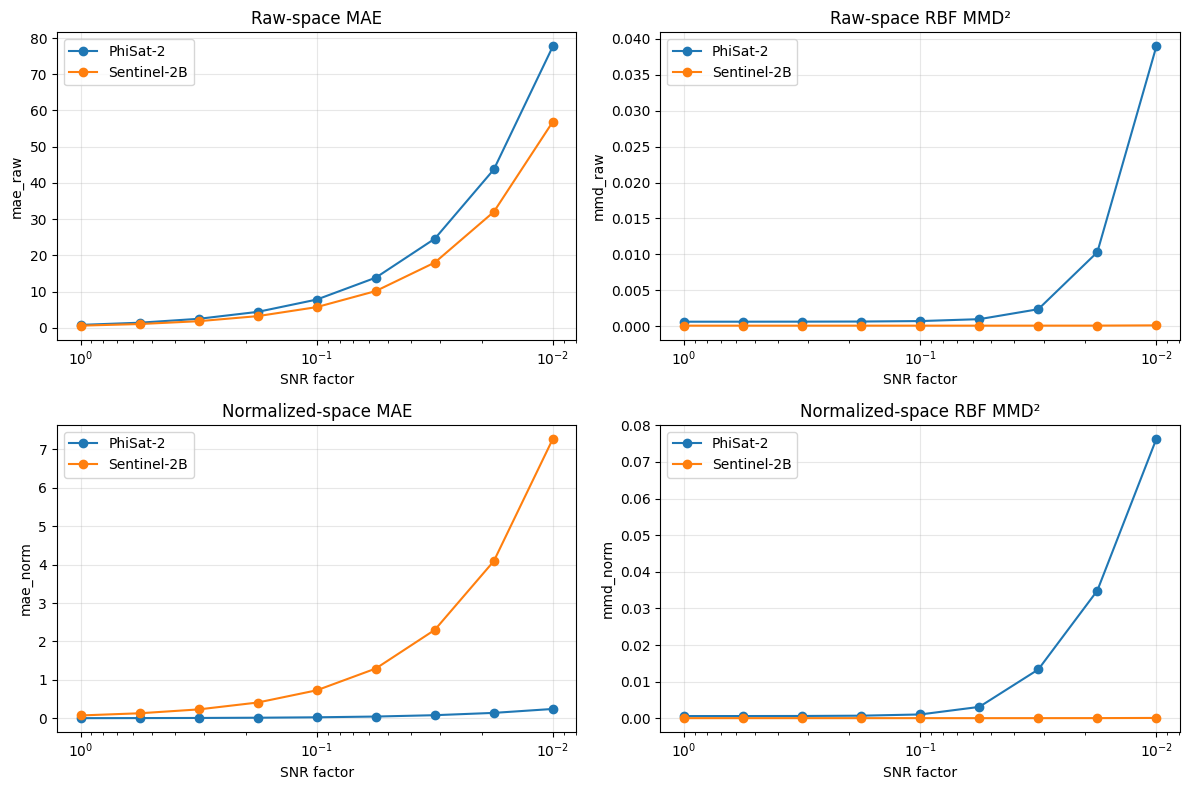

In [33]:
def plot_snr_metrics_before_after(results: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    metrics = [
        ("mae_raw", "Raw-space MAE"),
        ("mmd_raw", "Raw-space RBF MMD²"),
        ("mae_norm", "Normalized-space MAE"),
        ("mmd_norm", "Normalized-space RBF MMD²"),
    ]

    for ax, (metric, title) in zip(axes.ravel(), metrics):
        for sensor, df_sensor in results.groupby("sensor"):
            df_sensor = df_sensor.sort_values("snr_factor", ascending=False)

            ax.plot(
                df_sensor["snr_factor"],
                df_sensor[metric],
                marker="o",
                label=sensor,
            )

        ax.set_xscale("log")
        ax.invert_xaxis()
        ax.set_xlabel("SNR factor")
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_snr_metrics_before_after(snr_results)

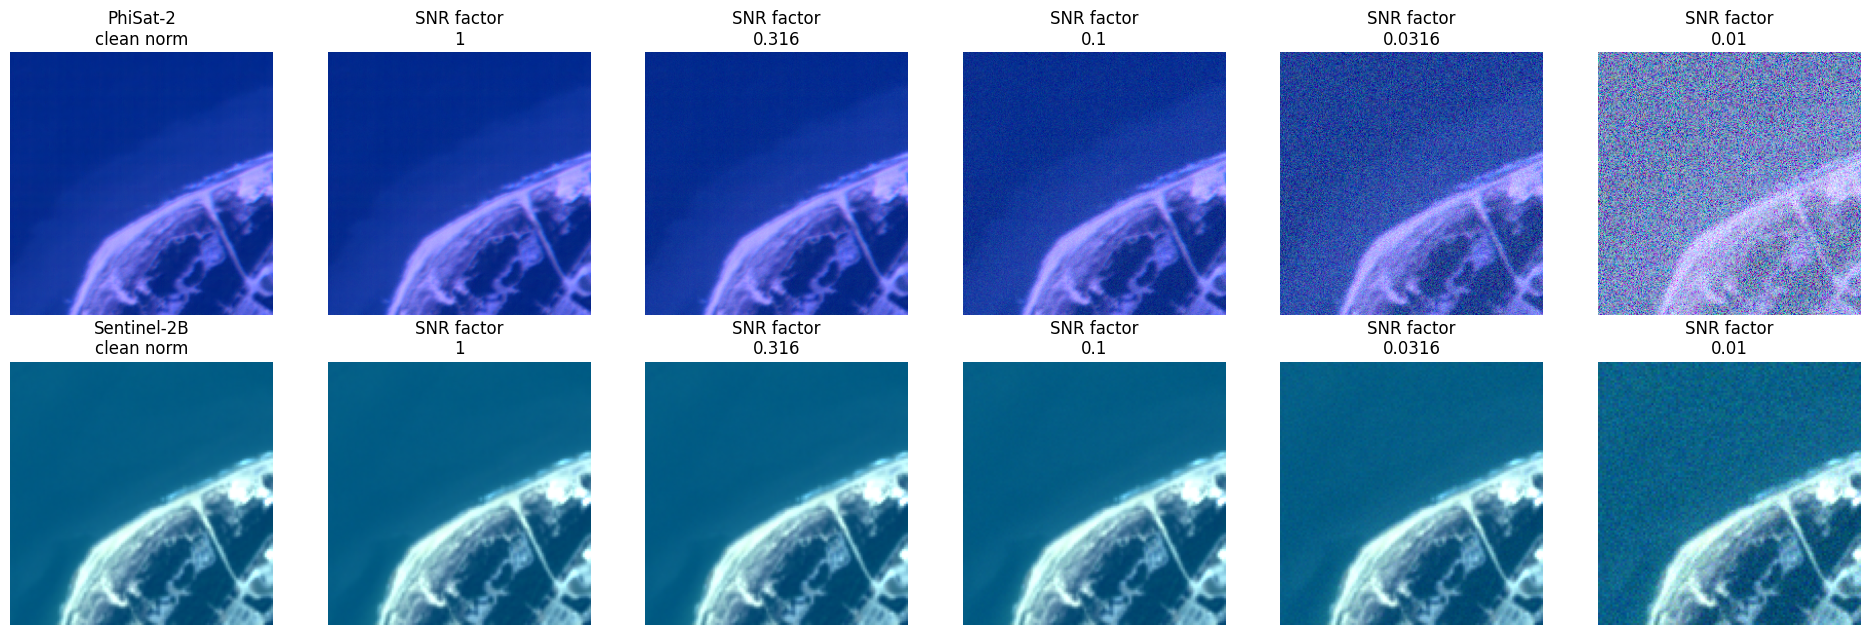

In [34]:
def plot_snr_image_grid_before_after_norm(
    clean_norm: dict,
    perturbed_norm: dict,
    strengths_to_show=(1.0, 0.31622776, 0.1, 0.03162278, 0.01),
):
    """
    Shows normalized clean and normalized-after-raw-SNR images.
    Each row is a different sensor.
    """
    sensors = ["PhiSat-2", "Sentinel-2B"]
    sensor_keys = {
        "PhiSat-2": "phisat2",
        "Sentinel-2B": "s2",
    }

    n_rows = len(sensors)
    n_cols = len(strengths_to_show) + 1

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.2 * n_cols, 3.2 * n_rows),
    )

    for row_idx, sensor_name in enumerate(sensors):
        sensor_key = sensor_keys[sensor_name]

        clean_rgb = make_rgb_for_plot(
            clean_norm[sensor_name],
            sensor=sensor_key,
            normalize=False,
        )

        axes[row_idx, 0].imshow(clean_rgb)
        axes[row_idx, 0].set_title(f"{sensor_name}\nclean norm")
        axes[row_idx, 0].axis("off")

        available_strengths = np.array(list(perturbed_norm[sensor_name].keys()))

        for col_idx, target_strength in enumerate(strengths_to_show, start=1):
            nearest_strength = float(
                available_strengths[np.argmin(np.abs(available_strengths - target_strength))]
            )

            x_noisy_norm = perturbed_norm[sensor_name][nearest_strength]

            rgb = make_rgb_for_plot(
                x_noisy_norm,
                sensor=sensor_key,
                normalize=False,
            )

            axes[row_idx, col_idx].imshow(rgb)
            axes[row_idx, col_idx].set_title(f"SNR factor\n{nearest_strength:.3g}")
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
    plt.show()


plot_snr_image_grid_before_after_norm(clean_norm, perturbed_norm)

In [ ]:
def nearest_strength_key(d: dict, target: float) -> float:
    keys = np.array(list(d.keys()), dtype=np.float64)
    return float(keys[np.argmin(np.abs(keys - target))])


def per_band_mae(x_ref, x_pert):
    return np.mean(np.abs(x_ref - x_pert), axis=(1, 2))


def inspect_snr_per_band(
    snr_factor=0.01,
    sensor_name="PhiSat-2",
):
    raw_clean = clean_raw[sensor_name]
    norm_clean = clean_norm[sensor_name]

    raw_key = nearest_strength_key(perturbed_raw[sensor_name], snr_factor)
    norm_key = nearest_strength_key(perturbed_norm[sensor_name], snr_factor)

    raw_noisy = perturbed_raw[sensor_name][raw_key]
    norm_noisy = perturbed_norm[sensor_name][norm_key]

    raw_band_mae = per_band_mae(raw_clean, raw_noisy)
    norm_band_mae = per_band_mae(norm_clean, norm_noisy)

    return pd.DataFrame({
        "band": np.arange(raw_clean.shape[0]),
        "raw_mae": raw_band_mae,
        "norm_mae": norm_band_mae,
        "used_snr_factor": raw_key,
    })


inspect_snr_per_band(0.01, "PhiSat-2")

,band,raw_mae,norm_mae,used_snr_factor
0,0,31.615593,0.117426,0.01
1,1,111.913910,0.253449,0.01
2,2,111.878998,0.444384,0.01
3,3,93.760864,0.410446,0.01
4,4,64.974266,0.104954,0.01
5,5,59.511787,0.091384,0.01
6,6,58.265896,0.104617,0.01
7,7,89.857117,0.410823,0.01


In [41]:
inspect_snr_per_band(0.01, "Sentinel-2B")

,band,raw_mae,norm_mae,used_snr_factor
0,0,66.314674,10.129944,0.01
1,1,61.099968,8.738803,0.01
2,2,60.528465,6.619183,0.01
3,3,50.892929,6.058754,0.01
4,4,61.422455,7.702840,0.01
5,5,50.817406,6.095186,0.01
6,6,47.329651,5.605852,0.01


Interpretation of SNR perturbation results

The SNR perturbation was applied in raw image space before the sensor-specific preprocessing and normalization steps. We then measured the perturbation magnitude both before normalization, using the raw images, and after normalization, using the actual model inputs. This distinction is important because the two sensors use different preprocessing pipelines, so raw-space perturbations do not propagate equally into normalized model space.

In raw space, the PhiSat-2 patches showed a larger MAE than the Sentinel-2B patches under strong SNR degradation. At an SNR factor of 0.01, PhiSat-2 reached a raw MAE of approximately 77.7, while Sentinel-2B reached approximately 56.9. This indicates that, under the chosen SNR and reference-radiance assumptions, the absolute additive noise injected into the PhiSat-2 raw data is larger.

However, after normalization, the trend reverses. At the same SNR factor of 0.01, PhiSat-2 has a normalized-space MAE of only approximately 0.24, while Sentinel-2B reaches approximately 7.28. This difference is caused by the sensor-specific preprocessing. PhiSat-2 is preprocessed using a square-root transform followed by clipping and z-score normalization:

x = sqrt(clip(x, 0, None))
x = clip(x, 0, sqrt(1500))
x = (x - mean) / std

The square-root transform compresses additive raw-space perturbations before they reach the normalized model input. Locally, this behaves approximately as:

Δsqrt(x) ≈ Δx / (2 sqrt(x))

so the same raw additive noise produces a much smaller change after the square-root transform, especially for brighter pixels.

In contrast, Sentinel-2B uses a mostly linear preprocessing pipeline:

x = clip(x, min, max)
x = (x - mean) / std

Therefore, raw-space noise propagates almost directly into normalized space as:

Δx_norm ≈ Δx_raw / std

Because the Sentinel-2B normalization standard deviations are relatively small, around 6.5–9.1 depending on the band, the raw SNR noise is strongly amplified in normalized coordinates. This is confirmed by the per-band results. For example, Sentinel-2B band 0 has a raw MAE of 66.31 and a normalization standard deviation of approximately 6.55, giving:

66.31 / 6.55 ≈ 10.13

which matches the observed normalized MAE of 10.13.

The per-band analysis also shows that PhiSat-2 raw perturbations can be large, particularly in the visible bands, but that these perturbations are heavily attenuated by the square-root preprocessing. For PhiSat-2 at SNR factor 0.01, raw per-band MAE values range from approximately 31.6 to 111.9, while normalized per-band MAE values remain between approximately 0.09 and 0.44. For Sentinel-2B, raw per-band MAE values range from approximately 47.3 to 66.3, but normalized per-band MAE values increase to approximately 5.6–10.1.

The MMD results provide a complementary view. PhiSat-2 shows a much stronger increase in RBF-MMD under severe SNR degradation, especially in normalized space, while Sentinel-2B MMD remains comparatively small despite its large normalized MAE. This suggests that the Sentinel-2B perturbation primarily increases pixelwise error without substantially changing the global multiband feature distribution under the chosen RBF kernel bandwidth. PhiSat-2, on the other hand, exhibits a stronger distributional shift, likely because the perturbation interacts nonlinearly with the square-root preprocessing and with the different band ordering and PAN channel.

Overall, these results show that the apparent severity of an SNR perturbation depends strongly on where it is measured. In raw radiometric space, PhiSat-2 experiences larger absolute perturbations. In normalized model-input space, Sentinel-2B is more strongly affected because its linear z-score normalization directly scales raw noise by the inverse of the per-band dataset standard deviation. This highlights why robustness analyses should report both raw-space and normalized-space metrics: raw-space metrics describe the physical perturbation magnitude, while normalized-space metrics better describe the perturbation actually seen by the neural network.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# MTF@Nyquist values to sweep.
# Lower MTF@Nyquist = stronger optical blur.
#
# Sentinel-2 nominal default used earlier: ~0.225
# PhiSat-2 nominal default used earlier: ~0.0555
MTF_NYQUIST_VALUES = np.array(
    [0.45, 0.30, 0.225, 0.15, 0.10, 0.075, 0.0555, 0.039, 0.025, 0.01],
    dtype=np.float32,
)


def apply_mtf_before_normalization(
    x_raw: np.ndarray,
    mtf_nyquist: float,
) -> np.ndarray:
    """
    Apply MTF blur in raw image space.

    The imported perturb_mtf() accepts:
        perturb_mtf(x, mtf_nyquist=None, k_grid=None)

    mtf_nyquist:
        MTF value at Nyquist frequency.
        Lower values mean stronger blur.
    """
    return perturb_mtf(
        x_raw,
        mtf_nyquist=float(mtf_nyquist),
    ).astype(np.float32)


def run_mtf_sweep_before_and_after_norm(
    x_phisat2_raw: np.ndarray,
    x_s2_raw: np.ndarray,
    mtf_values: np.ndarray = MTF_NYQUIST_VALUES,
    seed: int = 42,
    max_mmd_samples: int = 4096,
):
    """
    For each sensor and MTF@Nyquist value:

        1. apply MTF blur to raw image
        2. compute raw-space MAE/MMD
        3. normalize clean raw image
        4. normalize blurred raw image
        5. compute normalized-space MAE/MMD

    Returns:
        results: DataFrame
        clean_raw: dict
        clean_norm: dict
        perturbed_raw: dict
        perturbed_norm: dict
    """
    clean_raw = {
        "PhiSat-2": x_phisat2_raw.astype(np.float32),
        "Sentinel-2B": x_s2_raw.astype(np.float32),
    }

    sensor_keys = {
        "PhiSat-2": "phisat2",
        "Sentinel-2B": "s2",
    }

    clean_norm = {
        sensor_name: normalize_by_sensor(x_raw, sensor_keys[sensor_name])
        for sensor_name, x_raw in clean_raw.items()
    }

    perturbed_raw = {
        "PhiSat-2": {},
        "Sentinel-2B": {},
    }

    perturbed_norm = {
        "PhiSat-2": {},
        "Sentinel-2B": {},
    }

    rows = []

    for sensor_name, x_clean_raw in clean_raw.items():
        sensor_key = sensor_keys[sensor_name]
        x_clean_norm = clean_norm[sensor_name]

        for mtf_value in mtf_values:
            mtf_value = float(mtf_value)

            x_blur_raw = apply_mtf_before_normalization(
                x_clean_raw,
                mtf_nyquist=mtf_value,
            )

            x_blur_norm = normalize_by_sensor(x_blur_raw, sensor_key)

            perturbed_raw[sensor_name][mtf_value] = x_blur_raw
            perturbed_norm[sensor_name][mtf_value] = x_blur_norm

            rows.append(
                {
                    "sensor": sensor_name,
                    "mtf_nyquist": mtf_value,

                    "mae_raw": mae(x_clean_raw, x_blur_raw),
                    "mmd_raw": mmd_rbf(
                        x_clean_raw,
                        x_blur_raw,
                        max_samples=max_mmd_samples,
                        seed=seed,
                    ),

                    "mae_norm": mae(x_clean_norm, x_blur_norm),
                    "mmd_norm": mmd_rbf(
                        x_clean_norm,
                        x_blur_norm,
                        max_samples=max_mmd_samples,
                        seed=seed,
                    ),
                }
            )

    results = pd.DataFrame(rows)
    return results, clean_raw, clean_norm, perturbed_raw, perturbed_norm

In [43]:
mtf_results, mtf_clean_raw, mtf_clean_norm, mtf_perturbed_raw, mtf_perturbed_norm = run_mtf_sweep_before_and_after_norm(
    x_phisat2_raw,
    x_s2_raw,
    mtf_values=MTF_NYQUIST_VALUES,
    seed=42,
)

mtf_results

,sensor,mtf_nyquist,mae_raw,mmd_raw,mae_norm,mmd_norm
0,PhiSat-2,0.4500,17.314520,0.001577,0.039636,0.001606
1,PhiSat-2,0.3000,17.192627,0.001666,0.039099,0.001685
2,PhiSat-2,0.2250,16.985193,0.001628,0.038533,0.001649
3,PhiSat-2,0.1500,16.631964,0.001522,0.037654,0.001540
4,PhiSat-2,0.1000,16.273510,0.001402,0.036795,0.001420
5,PhiSat-2,0.0750,16.050514,0.001329,0.036266,0.001343
6,PhiSat-2,0.0555,15.848209,0.001272,0.035770,0.001283
7,PhiSat-2,0.0390,15.667719,0.001228,0.035318,0.001231
8,PhiSat-2,0.0250,15.519619,0.001193,0.034934,0.001192
9,PhiSat-2,0.0100,15.407136,0.001184,0.034596,0.001173


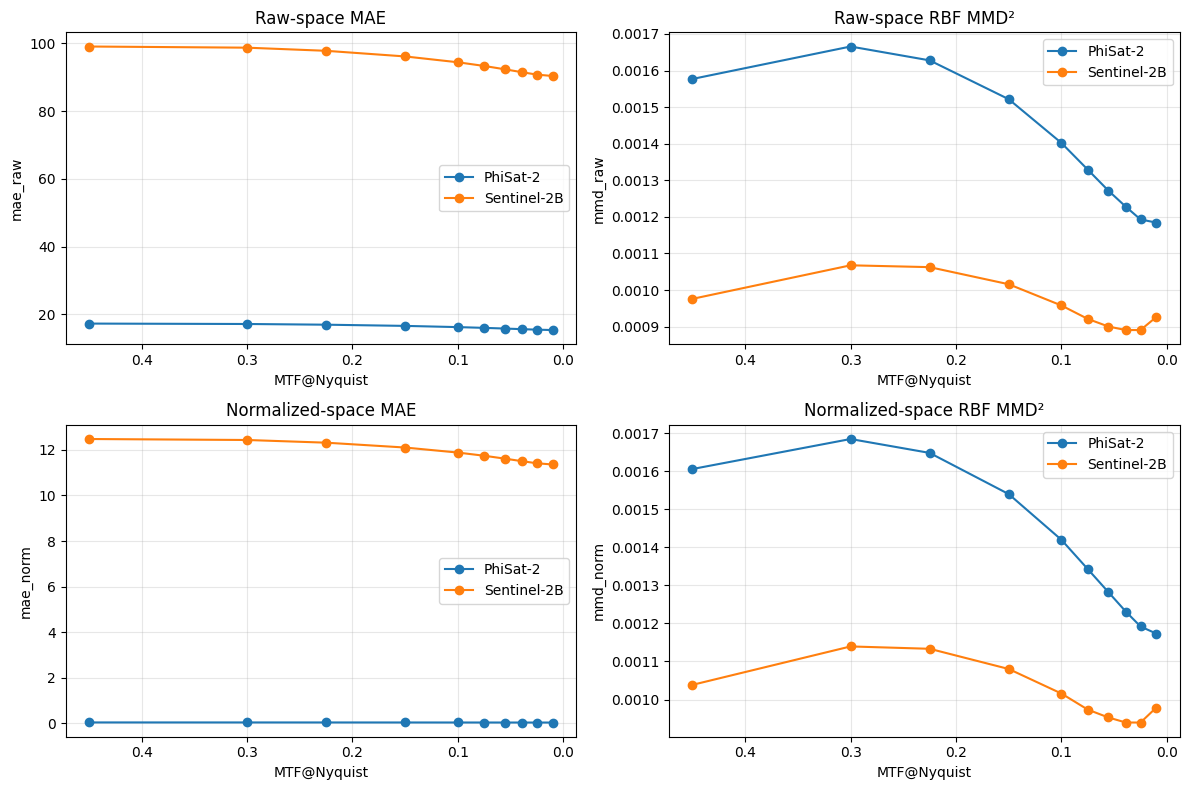

In [44]:
def plot_mtf_metrics_before_after(results: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    metrics = [
        ("mae_raw", "Raw-space MAE"),
        ("mmd_raw", "Raw-space RBF MMD²"),
        ("mae_norm", "Normalized-space MAE"),
        ("mmd_norm", "Normalized-space RBF MMD²"),
    ]

    for ax, (metric, title) in zip(axes.ravel(), metrics):
        for sensor, df_sensor in results.groupby("sensor"):
            df_sensor = df_sensor.sort_values("mtf_nyquist", ascending=False)

            ax.plot(
                df_sensor["mtf_nyquist"],
                df_sensor[metric],
                marker="o",
                label=sensor,
            )

        ax.invert_xaxis()
        ax.set_xlabel("MTF@Nyquist")
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_mtf_metrics_before_after(mtf_results)

0.45 17.31452 1.9502606 1728.7247
0.225 16.985193 2.4442644 1712.6042
0.9 16.748774 0.4737685 1794.4773
1e-08 17.754766 6.3560677 1688.858


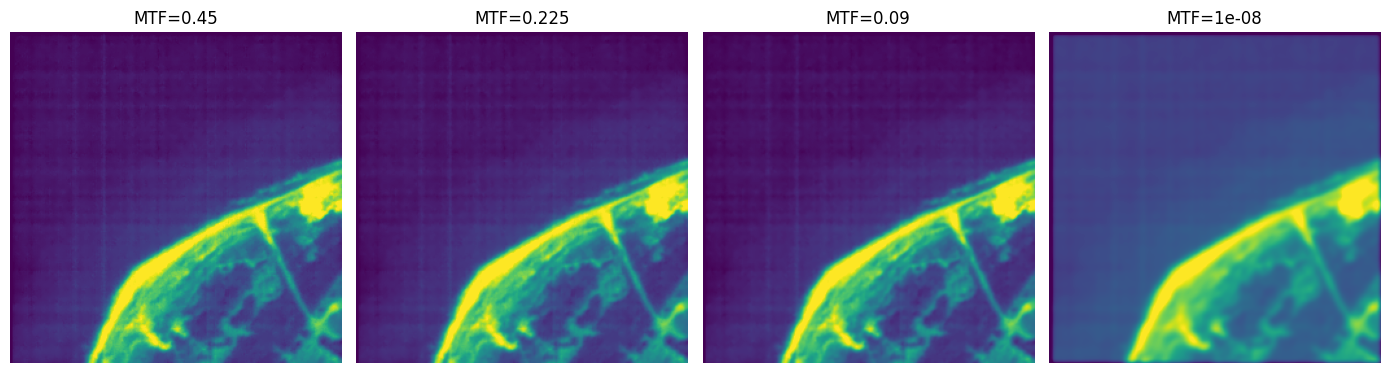

In [53]:
for m in  [0.45, 0.225, 0.9, 0.00000001]:
    x_blur = perturb_mtf(x_phisat2_raw, mtf_nyquist=m)
    print(m, np.mean(np.abs(x_phisat2_raw - x_blur)), x_blur.min(), x_blur.max())

b = 4
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, m in zip(axes, [0.45, 0.225, 0.09, 0.00000001]):
    x_blur = perturb_mtf(x_phisat2_raw, mtf_nyquist=m)
    ax.imshow(robust_minmax(x_blur[b]))
    ax.set_title(f"MTF={m}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Interpretation of MTF perturbation results

The MTF perturbation was used to simulate optical blur by attenuating high spatial frequencies. Lower values of MTF@Nyquist correspond to stronger suppression of high-frequency image content and therefore stronger blur. The perturbation was applied in raw image space, after which both the clean and blurred images were passed through the same sensor-specific normalization pipeline used during model training.

Compared with the SNR perturbation, the MTF perturbation produced relatively small visual and quantitative changes over the nominal sensor ranges. This is expected because MTF@Nyquist defines the response only at the highest resolvable spatial frequency, while most natural image energy is concentrated at lower spatial frequencies. As a result, moderate reductions in MTF@Nyquist can leave the overall image appearance largely unchanged, with the main effect being a subtle loss of edge sharpness and fine spatial detail.

The effect became more visible only for very low MTF@Nyquist values, such as 0.001, where high-frequency attenuation is severe enough to produce noticeable blur. This indicates that the nominal MTF values represent realistic optical degradation rather than a visually extreme perturbation. Therefore, MAE and MMD remain relatively small and change only weakly across much of the tested range.

The MTF results should also be interpreted in light of the different spatial resolutions of the two inputs. PhiSat-2 patches are represented at 256×256, while Sentinel-2B patches are represented at 128×128. Since blur primarily affects spatial detail, the magnitude of the perturbation is partly confounded by resolution: higher-resolution inputs contain more fine-scale structure that can be attenuated by an optical blur model. Therefore, the MTF experiment evaluates each sensor at its native model-input resolution rather than providing a purely resolution-independent comparison.

Overall, the MTF perturbation behaves as expected: decreasing MTF@Nyquist gradually reduces image sharpness, but the effect is subtle over realistic sensor ranges. This suggests that MTF-based degradation may be better captured by edge-sensitive or high-frequency metrics, such as gradient error or high-frequency energy loss, in addition to global distributional metrics such as MAE and MMD.

In [54]:
BRIGHTNESS_FACTORS = np.array(
    [0.50, 0.60, 0.75, 0.90, 1.00, 1.10, 1.25, 1.50, 2.00],
    dtype=np.float32,
)

def apply_brightness_before_normalization(
    x_raw: np.ndarray,
    alpha: float,
) -> np.ndarray:
    return perturb_brightness(
        x_raw,
        alpha=float(alpha),
    ).astype(np.float32)


def run_brightness_sweep_before_and_after_norm(
    x_phisat2_raw: np.ndarray,
    x_s2_raw: np.ndarray,
    brightness_factors: np.ndarray = BRIGHTNESS_FACTORS,
    seed: int = 42,
    max_mmd_samples: int = 4096,
):
    clean_raw = {
        "PhiSat-2": x_phisat2_raw.astype(np.float32),
        "Sentinel-2B": x_s2_raw.astype(np.float32),
    }

    sensor_keys = {
        "PhiSat-2": "phisat2",
        "Sentinel-2B": "s2",
    }

    clean_norm = {
        sensor_name: normalize_by_sensor(x_raw, sensor_keys[sensor_name])
        for sensor_name, x_raw in clean_raw.items()
    }

    perturbed_raw = {
        "PhiSat-2": {},
        "Sentinel-2B": {},
    }

    perturbed_norm = {
        "PhiSat-2": {},
        "Sentinel-2B": {},
    }

    rows = []

    for sensor_name, x_clean_raw in clean_raw.items():
        sensor_key = sensor_keys[sensor_name]
        x_clean_norm = clean_norm[sensor_name]

        for alpha in brightness_factors:
            alpha = float(alpha)

            x_bright_raw = apply_brightness_before_normalization(
                x_clean_raw,
                alpha=alpha,
            )

            x_bright_norm = normalize_by_sensor(x_bright_raw, sensor_key)

            perturbed_raw[sensor_name][alpha] = x_bright_raw
            perturbed_norm[sensor_name][alpha] = x_bright_norm

            rows.append(
                {
                    "sensor": sensor_name,
                    "brightness_factor": alpha,

                    "mae_raw": mae(x_clean_raw, x_bright_raw),
                    "mmd_raw": mmd_rbf(
                        x_clean_raw,
                        x_bright_raw,
                        max_samples=max_mmd_samples,
                        seed=seed,
                    ),

                    "mae_norm": mae(x_clean_norm, x_bright_norm),
                    "mmd_norm": mmd_rbf(
                        x_clean_norm,
                        x_bright_norm,
                        max_samples=max_mmd_samples,
                        seed=seed,
                    ),
                }
            )

    results = pd.DataFrame(rows)
    return results, clean_raw, clean_norm, perturbed_raw, perturbed_norm

In [55]:
brightness_results, brightness_clean_raw, brightness_clean_norm, brightness_perturbed_raw, brightness_perturbed_norm = run_brightness_sweep_before_and_after_norm(
    x_phisat2_raw,
    x_s2_raw,
    brightness_factors=BRIGHTNESS_FACTORS,
    seed=42,
)

brightness_results

,sensor,brightness_factor,mae_raw,mmd_raw,mae_norm,mmd_norm
0,PhiSat-2,0.50,250.814529,0.813117,0.616810,0.713598
1,PhiSat-2,0.60,200.651627,0.635803,0.474602,0.563331
2,PhiSat-2,0.75,125.407265,0.416763,0.281952,0.315208
3,PhiSat-2,0.90,50.162918,0.082848,0.107791,0.060064
4,PhiSat-2,1.00,0.000000,0.000609,0.000000,0.000627
5,PhiSat-2,1.10,50.162914,0.072383,0.101059,0.050965
6,PhiSat-2,1.25,125.407265,0.318573,0.240391,0.229400
7,PhiSat-2,1.50,250.814529,0.550383,0.440575,0.451136
8,PhiSat-2,2.00,501.629059,0.817193,0.749299,0.695018
9,Sentinel-2B,0.50,954.828979,0.611003,121.660446,0.664647


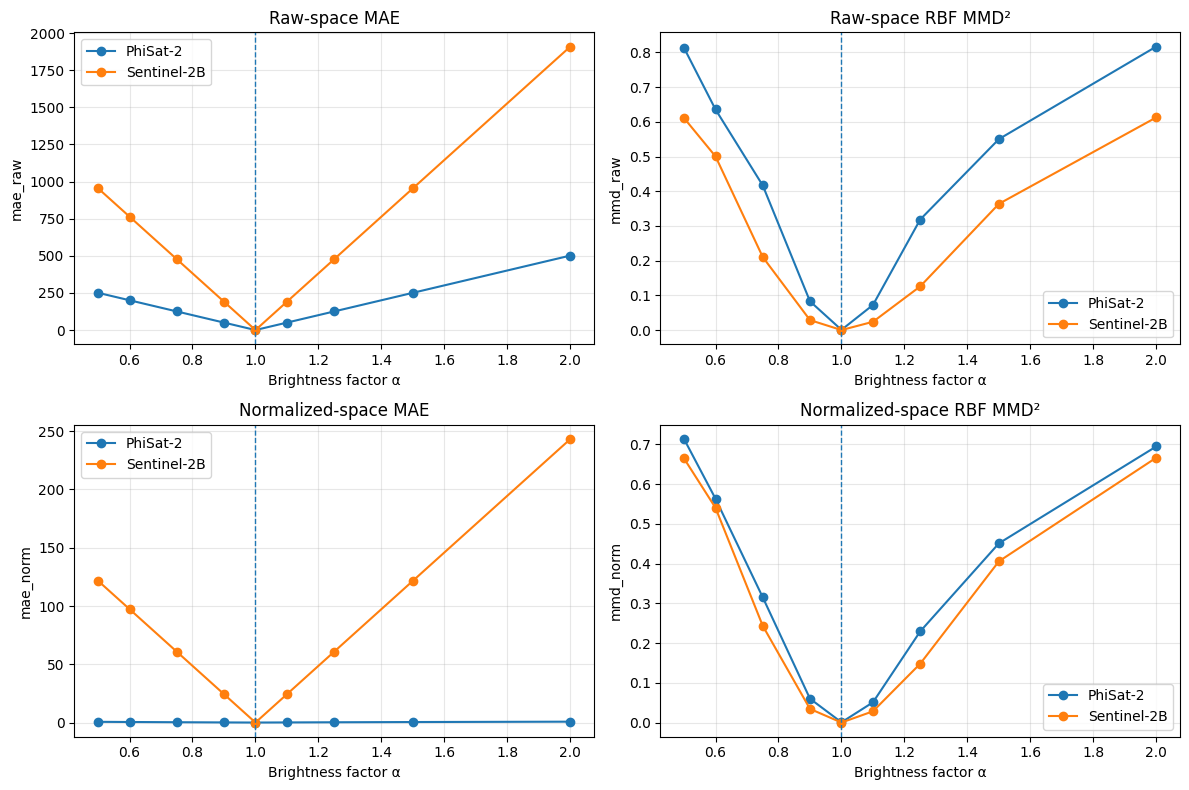

In [56]:
def plot_brightness_metrics_before_after(results: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    metrics = [
        ("mae_raw", "Raw-space MAE"),
        ("mmd_raw", "Raw-space RBF MMD²"),
        ("mae_norm", "Normalized-space MAE"),
        ("mmd_norm", "Normalized-space RBF MMD²"),
    ]

    for ax, (metric, title) in zip(axes.ravel(), metrics):
        for sensor, df_sensor in results.groupby("sensor"):
            df_sensor = df_sensor.sort_values("brightness_factor")

            ax.plot(
                df_sensor["brightness_factor"],
                df_sensor[metric],
                marker="o",
                label=sensor,
            )

        ax.axvline(1.0, linestyle="--", linewidth=1)
        ax.set_xlabel("Brightness factor α")
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_brightness_metrics_before_after(brightness_results)

Brightness perturbations produced the expected U-shaped response, with minimum MAE and MMD at the unperturbed setting α = 1. Deviations from this value increasingly shifted the image away from the clean reference. Sentinel-2B exhibited substantially larger MAE, especially after normalization, because its preprocessing is largely linear and therefore multiplicative raw-space changes propagate directly into z-scored model inputs. In contrast, PhiSat-2 preprocessing applies a square-root transform before normalization, which compresses raw brightness changes and reduces their pixelwise effect in normalized space. However, the MMD results indicate that PhiSat-2 still undergoes a noticeable distributional shift, even when normalized MAE remains small.

In [59]:
HAZE_TRANSMISSIONS = np.array(
    [1.00, 0.90, 0.75, 0.60, 0.45, 0.30, 0.20, 0.10],
    dtype=np.float32,
)

def apply_haze_before_normalization(
    x_raw: np.ndarray,
    t: float,
    atmospheric_light="p95",
) -> np.ndarray:
    return perturb_haze(
        x_raw,
        t=float(t),
        atmospheric_light=atmospheric_light,
    ).astype(np.float32)


def run_haze_sweep_before_and_after_norm(
    x_phisat2_raw: np.ndarray,
    x_s2_raw: np.ndarray,
    transmissions: np.ndarray = HAZE_TRANSMISSIONS,
    atmospheric_light="p95",
    seed: int = 42,
    max_mmd_samples: int = 4096,
):
    clean_raw = {
        "PhiSat-2": x_phisat2_raw.astype(np.float32),
        "Sentinel-2B": x_s2_raw.astype(np.float32),
    }

    sensor_keys = {
        "PhiSat-2": "phisat2",
        "Sentinel-2B": "s2",
    }

    clean_norm = {
        sensor_name: normalize_by_sensor(x_raw, sensor_keys[sensor_name])
        for sensor_name, x_raw in clean_raw.items()
    }

    perturbed_raw = {"PhiSat-2": {}, "Sentinel-2B": {}}
    perturbed_norm = {"PhiSat-2": {}, "Sentinel-2B": {}}

    rows = []

    for sensor_name, x_clean_raw in clean_raw.items():
        sensor_key = sensor_keys[sensor_name]
        x_clean_norm = clean_norm[sensor_name]

        for t in transmissions:
            t = float(t)

            x_hazy_raw = apply_haze_before_normalization(
                x_clean_raw,
                t=t,
                atmospheric_light=atmospheric_light,
            )

            x_hazy_norm = normalize_by_sensor(x_hazy_raw, sensor_key)

            perturbed_raw[sensor_name][t] = x_hazy_raw
            perturbed_norm[sensor_name][t] = x_hazy_norm

            rows.append({
                "sensor": sensor_name,
                "transmission": t,

                "mae_raw": mae(x_clean_raw, x_hazy_raw),
                "mmd_raw": mmd_rbf(
                    x_clean_raw,
                    x_hazy_raw,
                    max_samples=max_mmd_samples,
                    seed=seed,
                ),

                "mae_norm": mae(x_clean_norm, x_hazy_norm),
                "mmd_norm": mmd_rbf(
                    x_clean_norm,
                    x_hazy_norm,
                    max_samples=max_mmd_samples,
                    seed=seed,
                ),
            })

    results = pd.DataFrame(rows)
    return results, clean_raw, clean_norm, perturbed_raw, perturbed_norm

In [58]:
haze_results, haze_clean_raw, haze_clean_norm, haze_perturbed_raw, haze_perturbed_norm = run_haze_sweep_before_and_after_norm(
    x_phisat2_raw,
    x_s2_raw,
    transmissions=HAZE_TRANSMISSIONS,
    atmospheric_light="p95",
    seed=42,
)

haze_results

,sensor,transmission,mae_raw,mmd_raw,mae_norm,mmd_norm
0,PhiSat-2,1.00,0.000000,0.000609,0.000000,0.000627
1,PhiSat-2,0.90,36.128220,0.081913,0.104862,0.155141
2,PhiSat-2,0.75,90.320541,0.396807,0.242423,0.479107
3,PhiSat-2,0.60,144.512848,0.594823,0.366802,0.676178
4,PhiSat-2,0.45,198.705154,0.801233,0.482235,0.883355
5,PhiSat-2,0.30,252.897476,1.021682,0.590845,1.032292
6,PhiSat-2,0.20,289.025726,1.122567,0.660123,1.101762
7,PhiSat-2,0.10,325.153870,1.204409,0.727228,1.154053
8,Sentinel-2B,1.00,0.000000,0.000059,0.000000,0.000060
9,Sentinel-2B,0.90,144.422806,0.045781,17.773371,0.045318


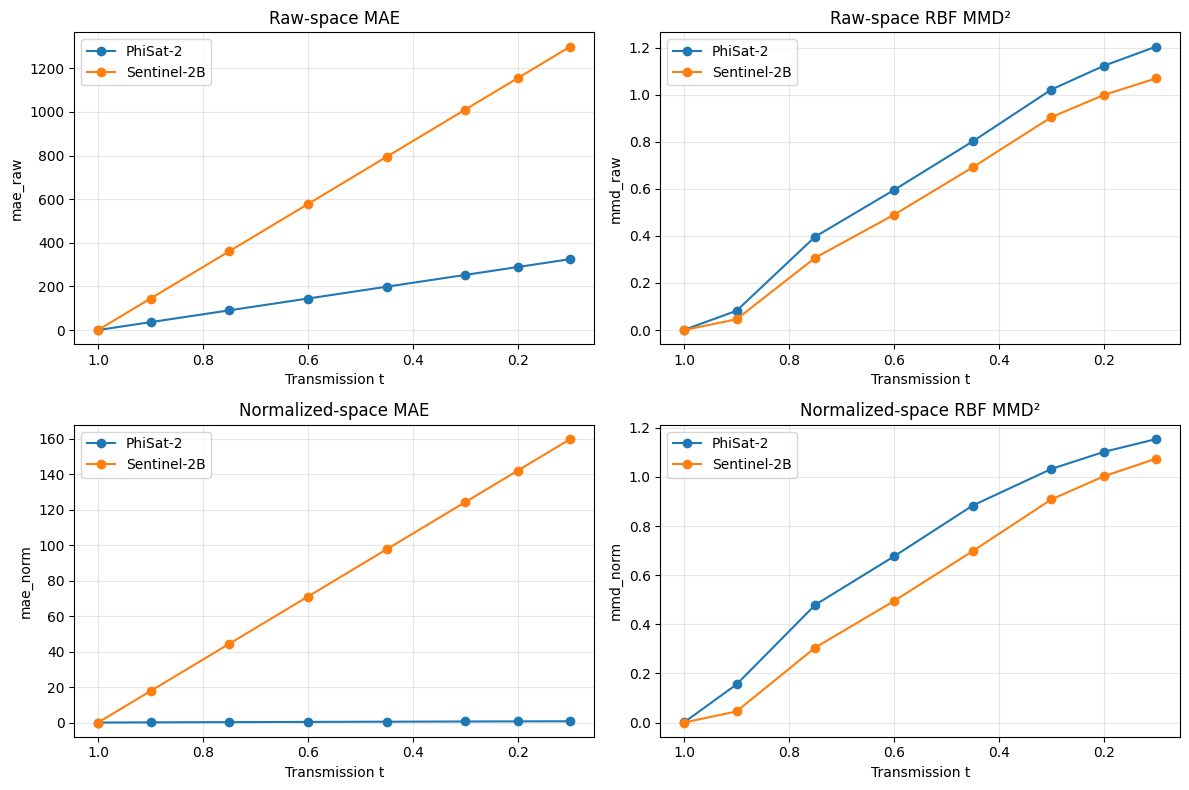

In [60]:
def plot_haze_metrics_before_after(results: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    metrics = [
        ("mae_raw", "Raw-space MAE"),
        ("mmd_raw", "Raw-space RBF MMD²"),
        ("mae_norm", "Normalized-space MAE"),
        ("mmd_norm", "Normalized-space RBF MMD²"),
    ]

    for ax, (metric, title) in zip(axes.ravel(), metrics):
        for sensor, df_sensor in results.groupby("sensor"):
            df_sensor = df_sensor.sort_values("transmission", ascending=False)

            ax.plot(
                df_sensor["transmission"],
                df_sensor[metric],
                marker="o",
                label=sensor,
            )

        ax.invert_xaxis()
        ax.set_xlabel("Transmission t")
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_haze_metrics_before_after(haze_results)